In [1]:
import pandas as pd
df = pd.read_csv("C:\\Users\\Ojasjoshi\\Downloads\\Pokemon.csv")
df = df.dropna()

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score,f1_score
import matplotlib.pyplot as plt

In [3]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False


In [5]:
y = df["Type 1"]
X = df[["HP","Attack","Defense","Speed"]]
scaler = StandardScaler()
X = scaler.fit_transform(X)
log_reg = LogisticRegression(max_iter=4000)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=4000)

In [6]:
pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test,pred)
accuracy

0.1566265060240964

In [7]:
# TASK 2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [8]:
# Creating new column
df['CAS'] = df['Attack'] + df['Sp. Atk'] + df['Speed'] * 0.5

In [9]:
# The model
y = df['CAS']
X = df[["HP","Defense","Sp. Def", "Total"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #splitting the data
model = LinearRegression() #Training the model
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(X_test) #predicting with the data
mse = mean_squared_error(y_test, y_pred) #calculating MSE
mse 

59.95874984454442

Text(0.5, 1.0, 'Predicted vs. Actual CAS')

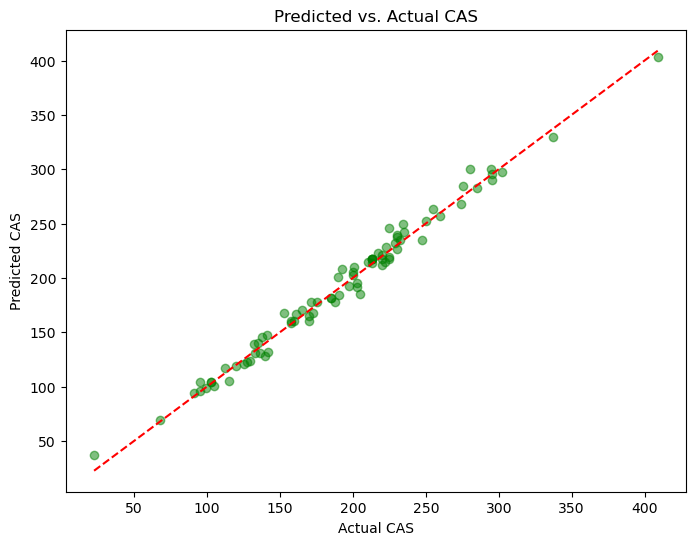

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')  # Diagonal line
plt.xlabel('Actual CAS')
plt.ylabel('Predicted CAS')
plt.title('Predicted vs. Actual CAS')

In [24]:
# TASK 3
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "CAS"]
X = df[features]
y = df["Legendary"].astype(int) #gets output as 1 or 0

In [42]:
# using logistic regression
log_reg3 = LogisticRegression(max_iter=4000)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)
log_reg3.fit(X_train, y_train)
pred2 = log_reg3.predict(X_test)
accuracy = accuracy_score(y_test,pred2)
f1 = f1_score(y_test,pred2)
print("accuracy: ",accuracy)
print("f1 score: ",f1)

accuracy:  0.927710843373494
f1 score:  0.4


In [44]:
# using linear regression
lin_reg3 = LinearRegression()
lin_reg3.fit(X_train,y_train)
lin_pred = log_reg3.predict(X_test) 
lin_accuracy = accuracy_score(y_test, lin_pred)
f1 = f1_score(y_test,pred2)
print("accuracy:", lin_accuracy)
print("f1 score: ",f1)

accuracy: 0.927710843373494
f1 score:  0.4


In [46]:
# using random forest
from sklearn.ensemble import RandomForestClassifier

In [52]:
random_forest = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
random_forest.fit(X_train,y_train)
forest_pred = random_forest.predict(X_test)
forest_accuracy = accuracy_score(y_test,forest_pred)
forest_f1 = f1_score(y_test,forest_pred)
print("accuracy:", forest_accuracy)
print("f1 score: ",forest_f1)

accuracy: 0.9156626506024096
f1 score:  0.36363636363636365
